In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [3]:
X,y=make_classification(n_features=5,n_redundant=0,n_informative=5,n_clusters_per_class=1)

In [6]:
df=pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])


In [8]:
df['target']=y

In [10]:
df.head()

,col1,col2,col3,col4,col5,target
0,2.090531,2.058937,-1.751099,0.521379,2.666481,0
1,-1.781029,1.789275,1.899018,-0.535304,1.076202,1
2,-1.151146,-0.306372,-1.185346,-1.063631,2.198756,1
3,1.634030,4.010620,-2.838846,0.958605,0.841399,0
4,1.044852,2.552485,-1.905901,-0.241348,0.181191,0


In [11]:
df.shape

(100, 6)

In [13]:
#function for row sampling
def sample_rows(df,percent):
    return df.sample(int(percent*df.shape[0]),replace=True)#pandas provide direct sample method for rows

In [15]:
def sample_features(df,percent):
    cols=random.sample(df.columns.tolist()[:-1],int(percent*df.shape[1]))#columns are selected excluding last column,out of which some percent of columns are selected
    return df[cols]

In [17]:
def combined_sample(df,row_percent,col_percent):
    new_df=sample_rows(df,row_percent)
    return sample_features(new_df,col_percent)

In [23]:
df1=sample_rows(df,0.50)

In [24]:
df1.shape

(50, 6)

In [25]:
from sklearn.tree import DecisionTreeClassifier
clf1=DecisionTreeClassifier()
clf2=DecisionTreeClassifier()
clf3=DecisionTreeClassifier()

In [27]:
df1=sample_rows(df,0.1)

In [28]:
df1

,col1,col2,col3,col4,col5,target
44,-2.779216,2.349178,3.077571,-0.655858,0.640836,1
93,-2.094903,-0.195445,0.047774,-1.678339,0.060566,1
72,-2.825838,-3.610728,-3.723936,-3.595543,0.605959,1
91,1.336238,-0.054742,-1.359526,-1.267056,1.057903,0
10,0.728295,-0.044505,-0.662465,-0.048974,1.323635,1
43,1.578695,3.322003,-2.846058,0.794951,-0.045214,0
3,1.634030,4.010620,-2.838846,0.958605,0.841399,0
72,-2.825838,-3.610728,-3.723936,-3.595543,0.605959,1
63,2.013671,4.009760,-2.427921,1.436779,2.145715,0
39,1.718708,-3.730210,-2.918206,0.291817,-0.775752,1


In [29]:
df2=sample_rows(df,0.1)

In [30]:
df2

,col1,col2,col3,col4,col5,target
52,2.558109,0.471924,-2.313398,0.582982,2.312821,0
18,0.467016,-4.966676,-3.601687,-1.143007,-1.524461,1
63,2.013671,4.009760,-2.427921,1.436779,2.145715,0
84,0.979661,-1.783546,-1.033292,0.190646,-0.112755,1
47,1.402832,4.203970,-2.505509,1.054093,0.511654,0
34,1.241310,2.215465,-1.400112,-0.335814,1.730337,0
27,-0.140818,-0.956697,-0.945915,-1.368394,-0.413350,1
10,0.728295,-0.044505,-0.662465,-0.048974,1.323635,1
12,-3.752263,2.764474,2.166156,-1.511577,2.957306,1
48,-0.763141,-4.741375,-3.891413,-2.873549,-1.848617,1


In [31]:
df3=sample_rows(df,0.1)

In [32]:
df3

,col1,col2,col3,col4,col5,target
84,0.979661,-1.783546,-1.033292,0.190646,-0.112755,1
66,-2.892072,0.506169,1.898924,-2.531584,-1.720263,1
39,1.718708,-3.730210,-2.918206,0.291817,-0.775752,1
60,-1.833604,0.113710,-1.080412,-2.538959,1.004516,1
52,2.558109,0.471924,-2.313398,0.582982,2.312821,0
42,0.924916,1.164743,-1.591460,-1.095297,0.176808,0
22,-0.044638,1.463911,-0.837637,-2.063297,-1.038948,0
49,0.296414,-1.778792,-2.040507,-0.079454,1.589594,1
16,-0.603406,-0.105774,3.112460,-3.176183,2.917034,0
18,0.467016,-4.966676,-3.601687,-1.143007,-1.524461,1


In [33]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

DecisionTreeClassifier()

In [34]:
from sklearn.tree import plot_tree

[Text(0.4, 0.8333333333333334, 'x[0] <= 1.032\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[1] <= -1.892\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]')]

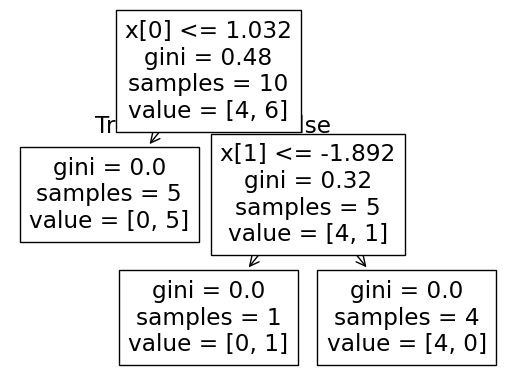

In [35]:
plot_tree(clf1)

[Text(0.5, 0.75, 'x[0] <= 1.11\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.625, 0.5, '  False')]

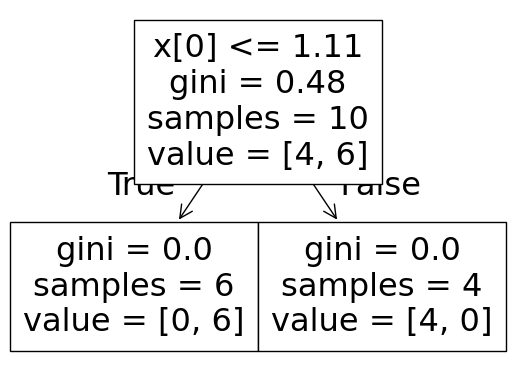

In [36]:
plot_tree(clf2)

[Text(0.4, 0.8333333333333334, 'x[1] <= -0.942\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[0] <= -1.219\ngini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]')]

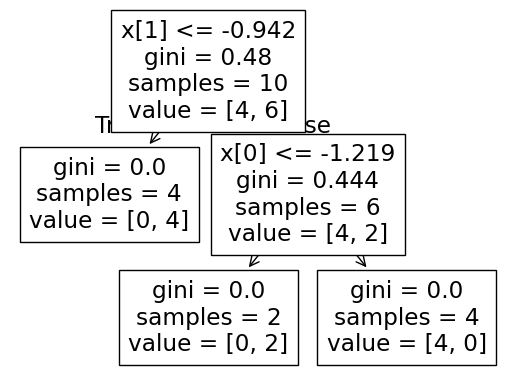

In [37]:
plot_tree(clf3)

In [38]:
df.head()

,col1,col2,col3,col4,col5,target
0,2.090531,2.058937,-1.751099,0.521379,2.666481,0
1,-1.781029,1.789275,1.899018,-0.535304,1.076202,1
2,-1.151146,-0.306372,-1.185346,-1.063631,2.198756,1
3,1.634030,4.010620,-2.838846,0.958605,0.841399,0
4,1.044852,2.552485,-1.905901,-0.241348,0.181191,0


In [39]:
clf1.predict(np.array([2.090531	,2.058937	,-1.751099	,0.521379,	2.666481]).reshape(1,5))

C:\Users\TANUSHREE\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [40]:
clf2.predict(np.array([2.090531	,2.058937	,-1.751099	,0.521379,	2.666481]).reshape(1,5))

C:\Users\TANUSHREE\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [41]:
clf3.predict(np.array([2.090531	,2.058937	,-1.751099	,0.521379,	2.666481]).reshape(1,5))

C:\Users\TANUSHREE\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [42]:
def sample_features(df,percent):
    cols=random.sample(df.columns.tolist()[:-1],int(percent*df.shape[1]))#columns are selected excluding last column,out of which some percent of columns are selected
    return df[cols]

In [44]:
import random
sample_features(df,0.50)

,col1,col5,col3
0,2.090531,2.666481,-1.751099
1,-1.781029,1.076202,1.899018
2,-1.151146,2.198756,-1.185346
3,1.634030,0.841399,-2.838846
4,1.044852,0.181191,-1.905901
...,...,...,...
95,0.755148,1.076472,-0.495404
96,1.214232,-0.400779,-2.634294
97,0.883721,0.183925,-0.885056
98,-2.198184,1.753233,-0.655848


In [45]:
def sample_features(df,percent):
    cols=random.sample(df.columns.tolist()[:-1],int(percent*df.shape[1]))#columns are selected excluding last column,out of which some percent of columns are selected
    new_df=df[cols]
    new_df['target']=df['target']
    return new_df

In [46]:
sample_features(df,0.50)

C:\Users\TANUSHREE\AppData\Local\Temp\ipykernel_26908\1717955903.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']


,col5,col4,col3,target
0,2.666481,0.521379,-1.751099,0
1,1.076202,-0.535304,1.899018,1
2,2.198756,-1.063631,-1.185346,1
3,0.841399,0.958605,-2.838846,0
4,0.181191,-0.241348,-1.905901,0
...,...,...,...,...
95,1.076472,-1.859055,-0.495404,0
96,-0.400779,-0.487430,-2.634294,0
97,0.183925,-1.912445,-0.885056,0
98,1.753233,-2.136875,-0.655848,1


In [48]:
df1=sample_features(df,0.50)
df1

C:\Users\TANUSHREE\AppData\Local\Temp\ipykernel_26908\1717955903.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']


,col2,col1,col5,target
0,2.058937,2.090531,2.666481,0
1,1.789275,-1.781029,1.076202,1
2,-0.306372,-1.151146,2.198756,1
3,4.010620,1.634030,0.841399,0
4,2.552485,1.044852,0.181191,0
...,...,...,...,...
95,0.039194,0.755148,1.076472,0
96,1.893937,1.214232,-0.400779,0
97,-0.851476,0.883721,0.183925,0
98,-0.109207,-2.198184,1.753233,1


In [49]:
df2=sample_features(df,0.50)
df2

C:\Users\TANUSHREE\AppData\Local\Temp\ipykernel_26908\1717955903.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']


,col3,col4,col5,target
0,-1.751099,0.521379,2.666481,0
1,1.899018,-0.535304,1.076202,1
2,-1.185346,-1.063631,2.198756,1
3,-2.838846,0.958605,0.841399,0
4,-1.905901,-0.241348,0.181191,0
...,...,...,...,...
95,-0.495404,-1.859055,1.076472,0
96,-2.634294,-0.487430,-0.400779,0
97,-0.885056,-1.912445,0.183925,0
98,-0.655848,-2.136875,1.753233,1


In [50]:
df3=sample_features(df,0.50)
df3

C:\Users\TANUSHREE\AppData\Local\Temp\ipykernel_26908\1717955903.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']


,col1,col2,col4,target
0,2.090531,2.058937,0.521379,0
1,-1.781029,1.789275,-0.535304,1
2,-1.151146,-0.306372,-1.063631,1
3,1.634030,4.010620,0.958605,0
4,1.044852,2.552485,-0.241348,0
...,...,...,...,...
95,0.755148,0.039194,-1.859055,0
96,1.214232,1.893937,-0.487430,0
97,0.883721,-0.851476,-1.912445,0
98,-2.198184,-0.109207,-2.136875,1


In [53]:
clf1.fit(df1.iloc[:,0:3],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:3],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:3],df3.iloc[:,-1])

DecisionTreeClassifier()

In [54]:
df1

,col2,col1,col5,target
0,2.058937,2.090531,2.666481,0
1,1.789275,-1.781029,1.076202,1
2,-0.306372,-1.151146,2.198756,1
3,4.010620,1.634030,0.841399,0
4,2.552485,1.044852,0.181191,0
...,...,...,...,...
95,0.039194,0.755148,1.076472,0
96,1.893937,1.214232,-0.400779,0
97,-0.851476,0.883721,0.183925,0
98,-0.109207,-2.198184,1.753233,1


In [55]:
clf1.predict(np.array([	-0.109207,	-2.198184	,1.753233]).reshape(1,3))

C:\Users\TANUSHREE\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [56]:
clf2.predict(np.array([	-0.109207,	-2.198184	,1.753233]).reshape(1,3))

C:\Users\TANUSHREE\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [57]:
clf3.predict(np.array([	-0.109207,	-2.198184	,1.753233]).reshape(1,3))

C:\Users\TANUSHREE\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

[Text(0.4230769230769231, 0.9285714285714286, 'x[1] <= 0.469\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.15384615384615385, 0.7857142857142857, 'x[1] <= -0.674\ngini = 0.226\nsamples = 54\nvalue = [7, 47]'),
 Text(0.28846153846153844, 0.8571428571428572, 'True  '),
 Text(0.07692307692307693, 0.6428571428571429, 'gini = 0.0\nsamples = 34\nvalue = [0, 34]'),
 Text(0.23076923076923078, 0.6428571428571429, 'x[0] <= -0.68\ngini = 0.455\nsamples = 20\nvalue = [7, 13]'),
 Text(0.15384615384615385, 0.5, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]'),
 Text(0.3076923076923077, 0.5, 'x[0] <= 0.647\ngini = 0.42\nsamples = 10\nvalue = [7, 3]'),
 Text(0.23076923076923078, 0.35714285714285715, 'x[0] <= -0.292\ngini = 0.5\nsamples = 6\nvalue = [3, 3]'),
 Text(0.15384615384615385, 0.21428571428571427, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.3076923076923077, 0.21428571428571427, 'x[1] <= -0.53\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.23076923076923078, 0.071428571428

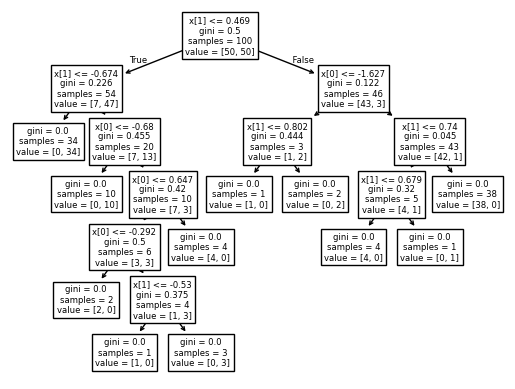

In [58]:
plot_tree(clf1)

[Text(0.4230769230769231, 0.9, 'x[0] <= 0.469\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.15384615384615385, 0.7, 'x[0] <= -0.674\ngini = 0.226\nsamples = 54\nvalue = [7, 47]'),
 Text(0.28846153846153844, 0.8, 'True  '),
 Text(0.07692307692307693, 0.5, 'gini = 0.0\nsamples = 34\nvalue = [0, 34]'),
 Text(0.23076923076923078, 0.5, 'x[2] <= -1.883\ngini = 0.455\nsamples = 20\nvalue = [7, 13]'),
 Text(0.15384615384615385, 0.3, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.3076923076923077, 0.3, 'x[1] <= 1.308\ngini = 0.231\nsamples = 15\nvalue = [2, 13]'),
 Text(0.23076923076923078, 0.1, 'gini = 0.0\nsamples = 13\nvalue = [0, 13]'),
 Text(0.38461538461538464, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.6923076923076923, 0.7, 'x[1] <= -1.627\ngini = 0.122\nsamples = 46\nvalue = [43, 3]'),
 Text(0.5576923076923077, 0.8, '  False'),
 Text(0.5384615384615384, 0.5, 'x[2] <= -1.307\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.46153846153846156, 0.3, 'gini 

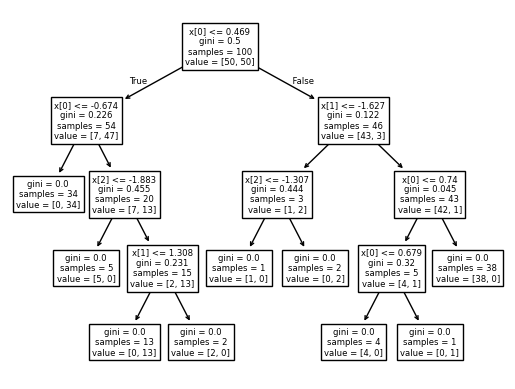

In [61]:
plot_tree(clf3)

[Text(0.532258064516129, 0.9444444444444444, 'x[1] <= -1.277\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.3064516129032258, 0.8333333333333334, 'x[1] <= -1.711\ngini = 0.463\nsamples = 44\nvalue = [16, 28]'),
 Text(0.4193548387096774, 0.8888888888888888, 'True  '),
 Text(0.1935483870967742, 0.7222222222222222, 'x[1] <= -2.51\ngini = 0.5\nsamples = 30\nvalue = [15, 15]'),
 Text(0.06451612903225806, 0.6111111111111112, 'x[2] <= -0.254\ngini = 0.337\nsamples = 14\nvalue = [3, 11]'),
 Text(0.03225806451612903, 0.5, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.0967741935483871, 0.5, 'x[2] <= 0.243\ngini = 0.5\nsamples = 6\nvalue = [3, 3]'),
 Text(0.06451612903225806, 0.3888888888888889, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.12903225806451613, 0.3888888888888889, 'x[2] <= 2.413\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.0967741935483871, 0.2777777777777778, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.16129032258064516, 0.2777777777777778, 'g

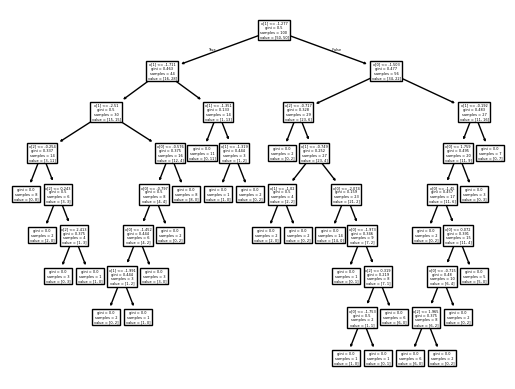

In [60]:
plot_tree(clf2)

In [81]:
def combined_sample(df,row_percent,col_percent):
    new_df=sample_rows(df,row_percent)
    return sample_features(new_df,col_percent)

In [82]:
df1=combined_sample(df,0.5,0.5)
df2=combined_sample(df,0.5,0.5)
df3=combined_sample(df,0.5,0.5)

C:\Users\TANUSHREE\AppData\Local\Temp\ipykernel_26908\1717955903.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']
C:\Users\TANUSHREE\AppData\Local\Temp\ipykernel_26908\1717955903.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']
C:\Users\TANUSHREE\AppData\Local\Temp\ipykernel_26908\1717955903.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

In [86]:
df1.head()

,col3,col2,col4,target
27,-0.945915,-0.956697,-1.368394,1
20,0.033945,-1.305946,-1.780731,0
88,-1.453976,-1.105435,0.239080,1
95,-0.495404,0.039194,-1.859055,0
62,0.949273,0.369678,-1.617558,1


In [88]:
clf1.fit(df1.iloc[:,0:3],df1.iloc[:,-1])

DecisionTreeClassifier()

In [89]:
clf2.fit(df2.iloc[:,0:3],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:3],df3.iloc[:,-1])

DecisionTreeClassifier()

In [92]:
clf1.predict(np.array([-0.945915,	-0.956697,	-1.368394]).reshape(1,3))

C:\Users\TANUSHREE\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [93]:
clf2.predict(np.array([-0.945915,	-0.956697,	-1.368394]).reshape(1,3))

C:\Users\TANUSHREE\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [94]:
clf3.predict(np.array([-0.945915,	-0.956697,	-1.368394]).reshape(1,3))

C:\Users\TANUSHREE\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

[Text(0.3958333333333333, 0.9285714285714286, 'x[1] <= -0.943\ngini = 0.471\nsamples = 50\nvalue = [19, 31]'),
 Text(0.16666666666666666, 0.7857142857142857, 'x[0] <= -0.296\ngini = 0.117\nsamples = 16\nvalue = [1, 15]'),
 Text(0.28125, 0.8571428571428572, 'True  '),
 Text(0.08333333333333333, 0.6428571428571429, 'gini = 0.0\nsamples = 15\nvalue = [0, 15]'),
 Text(0.25, 0.6428571428571429, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.625, 0.7857142857142857, 'x[0] <= 0.126\ngini = 0.498\nsamples = 34\nvalue = [18, 16]'),
 Text(0.5104166666666666, 0.8571428571428572, '  False'),
 Text(0.4166666666666667, 0.6428571428571429, 'x[1] <= -0.086\ngini = 0.386\nsamples = 23\nvalue = [17, 6]'),
 Text(0.25, 0.5, 'x[1] <= -0.379\ngini = 0.444\nsamples = 6\nvalue = [2, 4]'),
 Text(0.16666666666666666, 0.35714285714285715, 'x[2] <= -0.197\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.08333333333333333, 0.21428571428571427, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.25, 0.214

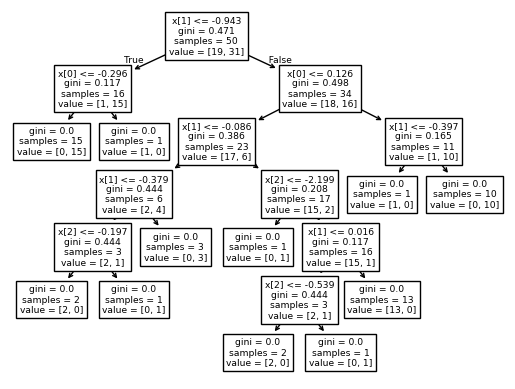

In [96]:
plot_tree(clf1)

[Text(0.2727272727272727, 0.9375, 'x[2] <= -1.696\ngini = 0.497\nsamples = 50\nvalue = [27, 23]'),
 Text(0.18181818181818182, 0.8125, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.22727272727272727, 0.875, 'True  '),
 Text(0.36363636363636365, 0.8125, 'x[0] <= -1.711\ngini = 0.474\nsamples = 44\nvalue = [27, 17]'),
 Text(0.3181818181818182, 0.875, '  False'),
 Text(0.18181818181818182, 0.6875, 'x[1] <= -0.216\ngini = 0.142\nsamples = 13\nvalue = [12, 1]'),
 Text(0.09090909090909091, 0.5625, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2727272727272727, 0.5625, 'gini = 0.0\nsamples = 12\nvalue = [12, 0]'),
 Text(0.5454545454545454, 0.6875, 'x[1] <= 0.53\ngini = 0.499\nsamples = 31\nvalue = [15, 16]'),
 Text(0.45454545454545453, 0.5625, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.6363636363636364, 0.5625, 'x[0] <= -1.004\ngini = 0.423\nsamples = 23\nvalue = [7, 16]'),
 Text(0.5454545454545454, 0.4375, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.72727272727272

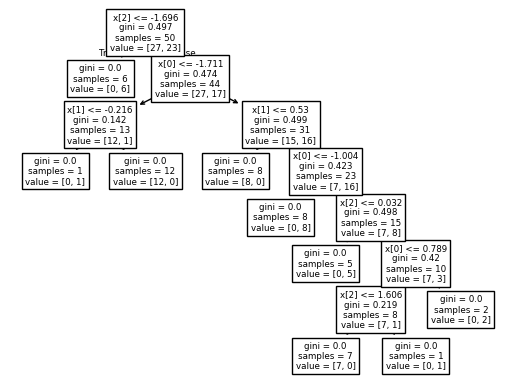

In [97]:
plot_tree(clf2)

[Text(0.7142857142857143, 0.9, 'x[0] <= 0.546\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.5714285714285714, 0.7, 'x[1] <= 3.021\ngini = 0.198\nsamples = 27\nvalue = [3, 24]'),
 Text(0.6428571428571428, 0.8, 'True  '),
 Text(0.42857142857142855, 0.5, 'x[2] <= -2.266\ngini = 0.142\nsamples = 26\nvalue = [2, 24]'),
 Text(0.2857142857142857, 0.3, 'x[0] <= -1.715\ngini = 0.48\nsamples = 5\nvalue = [2, 3]'),
 Text(0.14285714285714285, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.42857142857142855, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.5714285714285714, 0.3, 'gini = 0.0\nsamples = 21\nvalue = [0, 21]'),
 Text(0.7142857142857143, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8571428571428571, 0.7, 'gini = 0.0\nsamples = 23\nvalue = [23, 0]'),
 Text(0.7857142857142857, 0.8, '  False')]

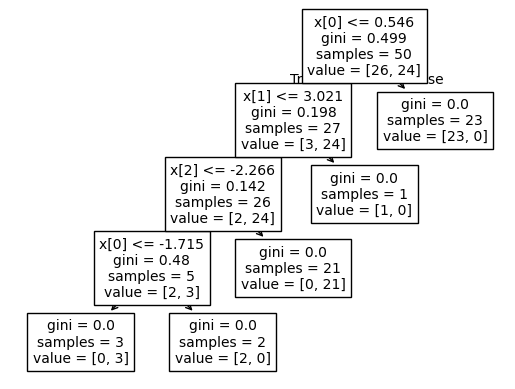

In [98]:
plot_tree(clf3)

In [99]:
!git add .

In [100]:
!git commit -m "my work"

[main 445f24f] my work
 3 files changed, 29 insertions(+)
 create mode 100644 randomforest/.ipynb_checkpoints/Untitled-checkpoint.ipynb
 create mode 100644 randomforest/Untitled.ipynb
 create mode 100644 randomforest/anaconda_projects/db/project_filebrowser.db


In [101]:
!git push origin main

To https://github.com/TANUSHRI-BHISE/LinearRegression.git
   625608d..445f24f  main -> main
